# 🎰 Two-Armed Bandit with ε-Greedy and Reward Plot (Gymnasium)

In [1]:
# ✅ Install Gymnasium and Matplotlib
# !pip install gymnasium matplotlib


In [2]:

import numpy as np
import random
import matplotlib.pyplot as plt
from gymnasium import Env, spaces


## 🧪 Define Custom 2-Armed Bandit Environment

In [3]:

class TwoArmedBanditEnv(Env):
    def __init__(self):
        super().__init__()
        self.action_space = spaces.Discrete(2)
        self.observation_space = spaces.Discrete(1)
        self.p_dist = [0.8, 0.2]  # Probabilities of reward

    def reset(self, seed=None, options=None):
        return 0, {}

    def step(self, action):
        assert self.action_space.contains(action)
        reward = 1 if random.random() < self.p_dist[action] else 0
        return 0, reward, False, False, {}


## 🎯 ε-Greedy Training and Reward Tracking

In [4]:

env = TwoArmedBanditEnv()
epsilon = 0.1
episodes = 1000
Q = np.zeros(env.action_space.n)
N = np.zeros(env.action_space.n)
reward_history = []

for episode in range(episodes):
    if random.random() < epsilon:
        action = env.action_space.sample()
    else:
        action = np.argmax(Q)

    _, reward, _, _, _ = env.step(action)
    reward_history.append(reward)

    N[action] += 1
    Q[action] += (reward - Q[action]) / N[action]

print("Final Q-values:")
for i in range(env.action_space.n):
    print(f"Arm {i}: Q = {Q[i]:.4f}, Pulled {int(N[i])} times")

print(f"Best Arm: Arm {np.argmax(Q)}")


Final Q-values:
Arm 0: Q = 0.8050, Pulled 954 times
Arm 1: Q = 0.2174, Pulled 46 times
Best Arm: Arm 0


## 📈 Plot Reward History (Cumulative Average)

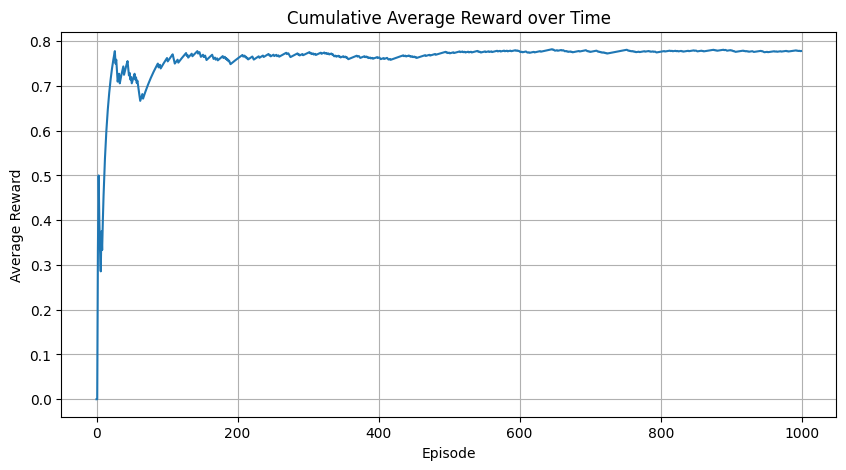

In [5]:

cumulative_avg = np.cumsum(reward_history) / (np.arange(1, len(reward_history) + 1))

plt.figure(figsize=(10, 5))
plt.plot(cumulative_avg)
plt.title("Cumulative Average Reward over Time")
plt.xlabel("Episode")
plt.ylabel("Average Reward")
plt.grid(True)
plt.show()
